In [12]:
import os
import csv
import random
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt

from rasterio.windows import Window
from rasterio.warp import reproject, Resampling


BASE_DIR = r"E:\Rasengan\Cloud-Removal"

CLOUDY_DIR = os.path.join(BASE_DIR, "data", "cloudy")
NON_CLOUDY_DIR = os.path.join(BASE_DIR, "data", "non cloudy")

PATCH_DIR = os.path.join(BASE_DIR, "data", "patches")
CLOUDY_PATCH_DIR = os.path.join(PATCH_DIR, "cloudy")
NON_CLOUDY_PATCH_DIR = os.path.join(PATCH_DIR, "non-cloudy")

METADATA_DIR = os.path.join(BASE_DIR, "metadata")
METADATA_FILE = os.path.join(METADATA_DIR, "patches_metadata.csv")


PATCH_SIZE = 256
STRIDE = 128
MIN_VALID = 0.90
MAX_PATCHES = 50

RANDOM_SEED = 42

os.makedirs(CLOUDY_PATCH_DIR, exist_ok=True)
os.makedirs(NON_CLOUDY_PATCH_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuration ready")
print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)
print("Maximum test pairs:", MAX_PATCHES)

Configuration ready
Patch size: 256
Stride: 128
Maximum test pairs: 50


In [13]:
print("Cloudy directory:")
print(CLOUDY_DIR)

print("\nFolders inside cloudy:")

for name in os.listdir(CLOUDY_DIR):
    path = os.path.join(CLOUDY_DIR, name)

    if os.path.isdir(path):
        print(name)

Cloudy directory:
E:\Rasengan\Cloud-Removal\data\cloudy

Folders inside cloudy:
ahemadabad1
ahemadabad2
chennai1
gumla1
gumla2
gumla3
jaipur1
jaipur2
jaipur3
katiyana1
katiyana2
mandi1
nzb1
nzb2
patna1
sambalpur1
sambalpur2
shilong
tirupati1
uttarpradesh1
yavatmal1
yavtmal2


In [14]:
PAIR_NAME = "gumla2"

cloudy_folder = os.path.join(CLOUDY_DIR, PAIR_NAME)
non_cloudy_folder = os.path.join(NON_CLOUDY_DIR, PAIR_NAME)

print("Cloudy folder:")
print(cloudy_folder)

print("\nFiles inside cloudy/gumla2:")
for name in os.listdir(cloudy_folder):
    print(name)

print("\nNon-cloudy folder:")
print(non_cloudy_folder)

print("\nFiles inside non-cloudy/gumla2:")
for name in os.listdir(non_cloudy_folder):
    print(name)

Cloudy folder:
E:\Rasengan\Cloud-Removal\data\cloudy\gumla2

Files inside cloudy/gumla2:
ACC_REP.txt
BAND2.tif
BAND3.tif
BAND4.tif
BAND_META.txt
RAF03OCT2025045780010400055SSANSTUC00GTDC.jpg
RAF03OCT2025045780010400055SSANSTUC00GTDC.jpg.aux.xml
RAF03OCT2025045780010400055SSANSTUC00GTDC.meta

Non-cloudy folder:
E:\Rasengan\Cloud-Removal\data\non cloudy\gumla2

Files inside non-cloudy/gumla2:
ACC_REP.txt
BAND2.tif
BAND3.tif
BAND4.tif
BAND_META.txt
RAF24FEB2026047827010400055SSANSTUC00GTDC.jpg
RAF24FEB2026047827010400055SSANSTUC00GTDC.jpg.aux.xml
RAF24FEB2026047827010400055SSANSTUC00GTDC.meta


In [15]:
def get_band_files(folder):
    files = {
        "B2": os.path.join(folder, "BAND2.TIF"),
        "B3": os.path.join(folder, "BAND3.TIF"),
        "B4": os.path.join(folder, "BAND4.TIF")
    }

    for band, path in files.items():
        if not os.path.isfile(path):
            raise FileNotFoundError(f"{band} file not found: {path}")

    return files


cloudy_files = get_band_files(cloudy_folder)
non_cloudy_files = get_band_files(non_cloudy_folder)

print("Cloudy bands:")
for band, path in cloudy_files.items():
    print(band, "✓", path)

print("\nNon-cloudy bands:")
for band, path in non_cloudy_files.items():
    print(band, "✓", path)

Cloudy bands:
B2 ✓ E:\Rasengan\Cloud-Removal\data\cloudy\gumla2\BAND2.TIF
B3 ✓ E:\Rasengan\Cloud-Removal\data\cloudy\gumla2\BAND3.TIF
B4 ✓ E:\Rasengan\Cloud-Removal\data\cloudy\gumla2\BAND4.TIF

Non-cloudy bands:
B2 ✓ E:\Rasengan\Cloud-Removal\data\non cloudy\gumla2\BAND2.TIF
B3 ✓ E:\Rasengan\Cloud-Removal\data\non cloudy\gumla2\BAND3.TIF
B4 ✓ E:\Rasengan\Cloud-Removal\data\non cloudy\gumla2\BAND4.TIF


In [16]:
for label, files in [("Cloudy", cloudy_files), ("Non-cloudy", non_cloudy_files)]:
    print(f"\n{label}")

    for band, path in files.items():
        with rasterio.open(path) as src:
            print(
                f"{band}: "
                f"shape={src.height} x {src.width}, "
                f"CRS={src.crs}, "
                f"resolution={src.res}, "
                f"dtype={src.dtypes[0]}"
            )


Cloudy
B2: shape=16224 x 18346, CRS=PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32645"]], resolution=(5.0, 5.0), dtype=uint16
B3: shape=16224 x 18346, CRS=PROJCS["WGS 84 / UTM zone 45N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_

In [17]:
for label, files in [("Cloudy", cloudy_files), ("Non-cloudy", non_cloudy_files)]:
    print(f"\n{label}")

    for band, path in files.items():
        with rasterio.open(path) as src:
            print(f"{band}:")
            print(src.transform)



Cloudy
B2:
| 5.00, 0.00, 164608.94|
| 0.00,-5.00, 2654982.50|
| 0.00, 0.00, 1.00|
B3:
| 5.00, 0.00, 164608.94|
| 0.00,-5.00, 2654982.50|
| 0.00, 0.00, 1.00|
B4:
| 5.00, 0.00, 164608.94|
| 0.00,-5.00, 2654982.50|
| 0.00, 0.00, 1.00|

Non-cloudy
B2:
| 5.00, 0.00, 165573.94|
| 0.00,-5.00, 2655092.50|
| 0.00, 0.00, 1.00|
B3:
| 5.00, 0.00, 165573.94|
| 0.00,-5.00, 2655092.50|
| 0.00, 0.00, 1.00|
B4:
| 5.00, 0.00, 165573.94|
| 0.00,-5.00, 2655092.50|
| 0.00, 0.00, 1.00|


In [18]:
with rasterio.open(cloudy_files["B2"]) as cloudy_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_src:

    dx = clear_src.transform.c - cloudy_src.transform.c
    dy = cloudy_src.transform.f - clear_src.transform.f

    pixel_dx = dx / cloudy_src.transform.a
    pixel_dy = dy / abs(cloudy_src.transform.e)

    print("X difference:", dx, "meters")
    print("Y difference:", dy, "meters")

    print("Column offset:", pixel_dx, "pixels")
    print("Row offset:", pixel_dy, "pixels")

    print("\nInteger alignment:",
          pixel_dx.is_integer() and pixel_dy.is_integer())

X difference: 965.0 meters
Y difference: -110.0 meters
Column offset: 193.0 pixels
Row offset: -22.0 pixels

Integer alignment: True


In [19]:
with rasterio.open(cloudy_files["B2"]) as cloudy_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_src:

    cloudy_left = cloudy_src.bounds.left
    cloudy_right = cloudy_src.bounds.right
    cloudy_top = cloudy_src.bounds.top
    cloudy_bottom = cloudy_src.bounds.bottom

    clear_left = clear_src.bounds.left
    clear_right = clear_src.bounds.right
    clear_top = clear_src.bounds.top
    clear_bottom = clear_src.bounds.bottom

    overlap_left = max(cloudy_left, clear_left)
    overlap_right = min(cloudy_right, clear_right)
    overlap_top = min(cloudy_top, clear_top)
    overlap_bottom = max(cloudy_bottom, clear_bottom)

    overlap_width_m = overlap_right - overlap_left
    overlap_height_m = overlap_top - overlap_bottom

    overlap_width_px = int(overlap_width_m / 5.0)
    overlap_height_px = int(overlap_height_m / 5.0)

    print("Common overlap:")
    print("Width :", overlap_width_m, "meters")
    print("Height:", overlap_height_m, "meters")
    print("Width :", overlap_width_px, "pixels")
    print("Height:", overlap_height_px, "pixels")

Common overlap:
Width : 90765.0 meters
Height: 80990.0 meters
Width : 18153 pixels
Height: 16198 pixels


In [20]:
with rasterio.open(cloudy_files["B2"]) as cloudy_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_src:

    cloudy_window = Window(
        col_off=193,
        row_off=22,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    clear_window = Window(
        col_off=0,
        row_off=0,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    cloudy_b2 = cloudy_src.read(1, window=cloudy_window)
    clear_b2 = clear_src.read(1, window=clear_window)

    print("Cloudy patch shape:", cloudy_b2.shape)
    print("Non-cloudy patch shape:", clear_b2.shape)

    cloudy_transform = cloudy_src.window_transform(cloudy_window)
    clear_transform = clear_src.window_transform(clear_window)

    print("\nCloudy patch transform:")
    print(cloudy_transform)

    print("\nNon-cloudy patch transform:")
    print(clear_transform)

    print("\nTop-left coordinates:")
    print("Cloudy    :", cloudy_transform.c, cloudy_transform.f)
    print("Non-cloudy:", clear_transform.c, clear_transform.f)

Cloudy patch shape: (256, 256)
Non-cloudy patch shape: (256, 256)

Cloudy patch transform:
| 5.00, 0.00, 165573.94|
| 0.00,-5.00, 2654872.50|
| 0.00, 0.00, 1.00|

Non-cloudy patch transform:
| 5.00, 0.00, 165573.94|
| 0.00,-5.00, 2655092.50|
| 0.00, 0.00, 1.00|

Top-left coordinates:
Cloudy    : 165573.94308370308 2654872.5
Non-cloudy: 165573.94308370308 2655092.5


In [21]:
with rasterio.open(cloudy_files["B2"]) as cloudy_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_src:

    cloudy_window = Window(
        col_off=193,
        row_off=0,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    clear_window = Window(
        col_off=0,
        row_off=22,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    cloudy_b2 = cloudy_src.read(1, window=cloudy_window)
    clear_b2 = clear_src.read(1, window=clear_window)

    cloudy_transform = cloudy_src.window_transform(cloudy_window)
    clear_transform = clear_src.window_transform(clear_window)

    print("Cloudy patch shape:", cloudy_b2.shape)
    print("Non-cloudy patch shape:", clear_b2.shape)

    print("\nCloudy top-left:")
    print(cloudy_transform.c, cloudy_transform.f)

    print("\nNon-cloudy top-left:")
    print(clear_transform.c, clear_transform.f)

    print("\nCoordinates match:",
          np.isclose(cloudy_transform.c, clear_transform.c) and
          np.isclose(cloudy_transform.f, clear_transform.f))

Cloudy patch shape: (256, 256)
Non-cloudy patch shape: (256, 256)

Cloudy top-left:
165573.94308370308 2654982.5

Non-cloudy top-left:
165573.94308370308 2654982.5

Coordinates match: True


In [22]:
with rasterio.open(cloudy_files["B2"]) as cloudy_b2_src, \
     rasterio.open(cloudy_files["B3"]) as cloudy_b3_src, \
     rasterio.open(cloudy_files["B4"]) as cloudy_b4_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_b2_src, \
     rasterio.open(non_cloudy_files["B3"]) as clear_b3_src, \
     rasterio.open(non_cloudy_files["B4"]) as clear_b4_src:

    cloudy_window = Window(
        col_off=193,
        row_off=0,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    clear_window = Window(
        col_off=0,
        row_off=22,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    cloudy_b2 = cloudy_b2_src.read(1, window=cloudy_window)
    cloudy_b3 = cloudy_b3_src.read(1, window=cloudy_window)
    cloudy_b4 = cloudy_b4_src.read(1, window=cloudy_window)

    clear_b2 = clear_b2_src.read(1, window=clear_window)
    clear_b3 = clear_b3_src.read(1, window=clear_window)
    clear_b4 = clear_b4_src.read(1, window=clear_window)

    cloudy_fcc = np.stack(
        [cloudy_b4, cloudy_b3, cloudy_b2],
        axis=-1
    )

    clear_fcc = np.stack(
        [clear_b4, clear_b3, clear_b2],
        axis=-1
    )

    print("Cloudy FCC shape:", cloudy_fcc.shape)
    print("Non-cloudy FCC shape:", clear_fcc.shape)

    print("\nCloudy dtype:", cloudy_fcc.dtype)
    print("Non-cloudy dtype:", clear_fcc.dtype)

    print("\nCloudy range:")
    print("B4:", cloudy_b4.min(), cloudy_b4.max())
    print("B3:", cloudy_b3.min(), cloudy_b3.max())
    print("B2:", cloudy_b2.min(), cloudy_b2.max())

Cloudy FCC shape: (256, 256, 3)
Non-cloudy FCC shape: (256, 256, 3)

Cloudy dtype: uint16
Non-cloudy dtype: uint16

Cloudy range:
B4: 0 0
B3: 0 0
B2: 0 0


In [25]:
for name, image in [("Cloudy", cloudy_fcc), ("Non-cloudy", clear_fcc)]:
    print(f"\n{name}")

    for channel, band in enumerate(["B4 (NIR)", "B3 (Red)", "B2 (Green)"]):
        values = image[:, :, channel]

        print(
            f"{band}: "
            f"min={values.min()}, "
            f"max={values.max()}, "
            f"mean={values.mean():.2f}, "
            f"unique={np.unique(values).size}"
        )


Cloudy
B4 (NIR): min=0, max=0, mean=0.00, unique=1
B3 (Red): min=0, max=0, mean=0.00, unique=1
B2 (Green): min=0, max=0, mean=0.00, unique=1

Non-cloudy
B4 (NIR): min=0, max=0, mean=0.00, unique=1
B3 (Red): min=0, max=0, mean=0.00, unique=1
B2 (Green): min=0, max=0, mean=0.00, unique=1


In [26]:
with rasterio.open(cloudy_files["B2"]) as src:
    print("Cloudy full-scene:")
    print("nodata:", src.nodata)

    positions = [
        (0, 0),
        (22, 193),
        (1000, 1000),
        (5000, 5000),
        (8000, 9000),
        (12000, 12000),
        (16000, 18000)
    ]

    for row, col in positions:
        window = Window(col, row, 256, 256)
        data = src.read(1, window=window)

        nonzero = np.count_nonzero(data)

        print(
            f"row={row:5d}, col={col:5d} | "
            f"min={data.min():5d}, "
            f"max={data.max():5d}, "
            f"nonzero={nonzero:6d}/{data.size}"
        )

Cloudy full-scene:
nodata: None
row=    0, col=    0 | min=    0, max=    0, nonzero=     0/65536
row=   22, col=  193 | min=    0, max=    0, nonzero=     0/65536
row= 1000, col= 1000 | min=    0, max=    0, nonzero=     0/65536
row= 5000, col= 5000 | min=  478, max=  751, nonzero= 65536/65536
row= 8000, col= 9000 | min=  394, max=  775, nonzero= 65536/65536
row=12000, col=12000 | min=  643, max=  738, nonzero= 65536/65536
row=16000, col=18000 | min=    0, max=    0, nonzero=     0/57344


In [27]:
def find_valid_bbox(path, scale=32):
    with rasterio.open(path) as src:
        small_height = max(1, src.height // scale)
        small_width = max(1, src.width // scale)

        data = src.read(
            1,
            out_shape=(small_height, small_width),
            resampling=rasterio.enums.Resampling.nearest
        )

        valid = data > 0

        rows, cols = np.where(valid)

        if len(rows) == 0:
            return None

        row_min = rows.min() * scale
        row_max = min((rows.max() + 1) * scale, src.height)

        col_min = cols.min() * scale
        col_max = min((cols.max() + 1) * scale, src.width)

        return row_min, row_max, col_min, col_max


cloudy_bbox = find_valid_bbox(cloudy_files["B2"])
clear_bbox = find_valid_bbox(non_cloudy_files["B2"])

print("Cloudy approximate valid bbox:")
print(cloudy_bbox)

print("\nNon-cloudy approximate valid bbox:")
print(clear_bbox)

Cloudy approximate valid bbox:
(np.int64(0), np.int64(16224), np.int64(0), np.int64(18336))

Non-cloudy approximate valid bbox:
(np.int64(0), np.int64(16192), np.int64(0), np.int64(18336))


Cloudy coarse shape: (253, 286)
Cloudy coarse min/max: 0 978

Non-cloudy coarse shape: (253, 286)
Non-cloudy coarse min/max: 0 302


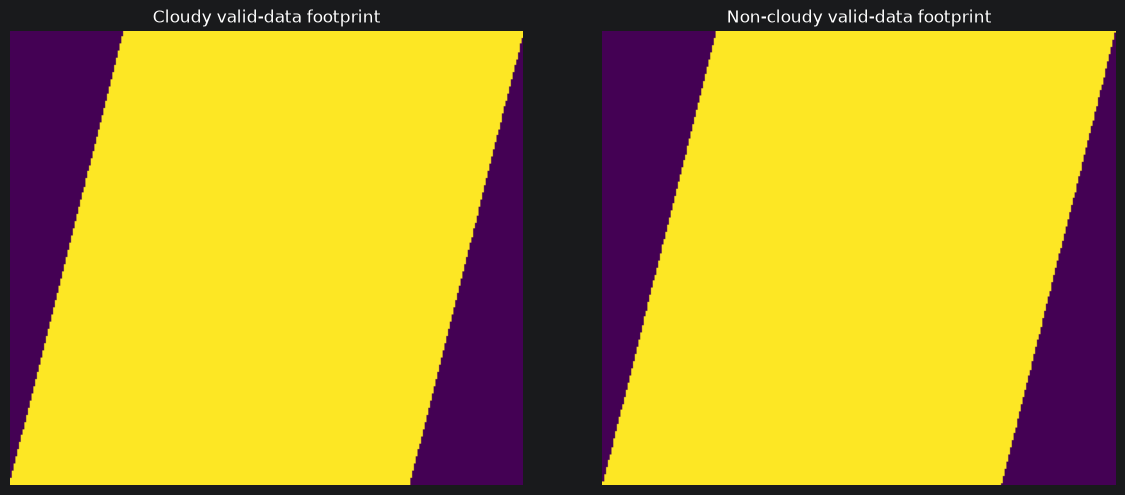

In [28]:
def coarse_valid_map(path, scale=64):
    with rasterio.open(path) as src:
        height = src.height
        width = src.width

        small_height = height // scale
        small_width = width // scale

        data = src.read(
            1,
            out_shape=(small_height, small_width),
            resampling=rasterio.enums.Resampling.average
        )

        return data


cloudy_coarse = coarse_valid_map(cloudy_files["B2"])
clear_coarse = coarse_valid_map(non_cloudy_files["B2"])

print("Cloudy coarse shape:", cloudy_coarse.shape)
print("Cloudy coarse min/max:", cloudy_coarse.min(), cloudy_coarse.max())

print("\nNon-cloudy coarse shape:", clear_coarse.shape)
print("Non-cloudy coarse min/max:", clear_coarse.min(), clear_coarse.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cloudy_coarse > 50)
plt.title("Cloudy valid-data footprint")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clear_coarse > 50)
plt.title("Non-cloudy valid-data footprint")
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
with rasterio.open(cloudy_files["B2"]) as cloudy_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_src:

    found = False

    for row in range(0, 16198 - PATCH_SIZE + 1, STRIDE):
        for col in range(0, 18153 - PATCH_SIZE + 1, STRIDE):

            cloudy_window = Window(
                col_off=193 + col,
                row_off=row,
                width=PATCH_SIZE,
                height=PATCH_SIZE
            )

            clear_window = Window(
                col_off=col,
                row_off=22 + row,
                width=PATCH_SIZE,
                height=PATCH_SIZE
            )

            cloudy = cloudy_src.read(1, window=cloudy_window)
            clear = clear_src.read(1, window=clear_window)

            cloudy_valid = np.mean(cloudy > 0)
            clear_valid = np.mean(clear > 0)

            if cloudy_valid >= MIN_VALID and clear_valid >= MIN_VALID:
                print("Valid patch found")
                print("Common row:", row)
                print("Common col:", col)
                print("Cloudy valid:", cloudy_valid)
                print("Non-cloudy valid:", clear_valid)

                found = True
                break

        if found:
            break

    if not found:
        print("No valid patch found")

Valid patch found
Common row: 0
Common col: 4096
Cloudy valid: 1.0
Non-cloudy valid: 1.0


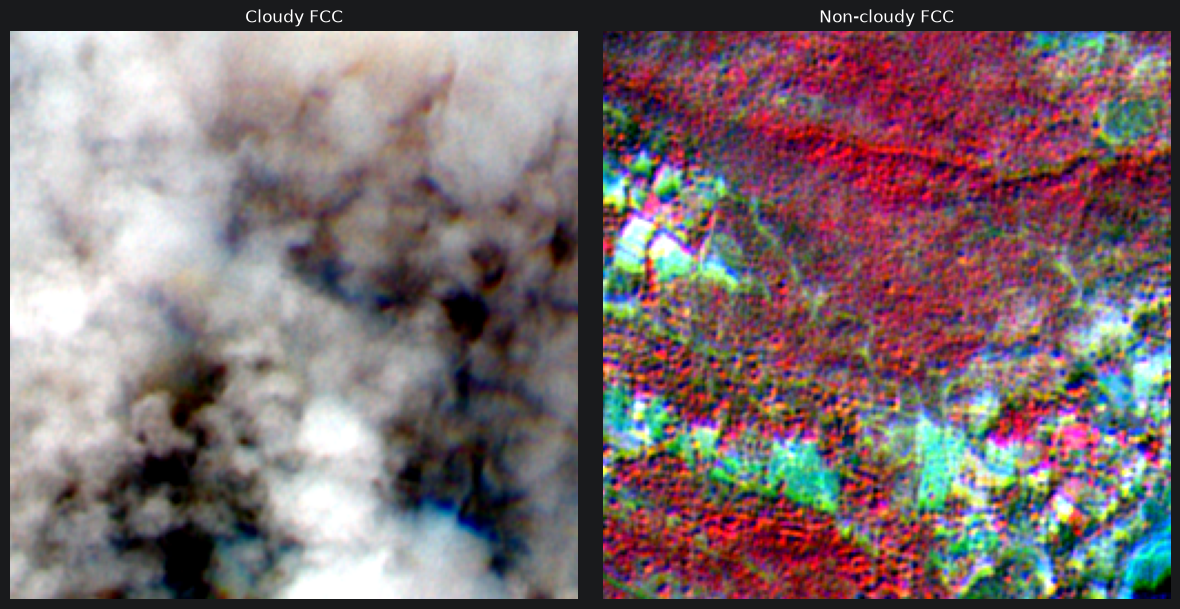

In [30]:
row = 0
col = 4096

with rasterio.open(cloudy_files["B2"]) as cloudy_b2_src, \
     rasterio.open(cloudy_files["B3"]) as cloudy_b3_src, \
     rasterio.open(cloudy_files["B4"]) as cloudy_b4_src, \
     rasterio.open(non_cloudy_files["B2"]) as clear_b2_src, \
     rasterio.open(non_cloudy_files["B3"]) as clear_b3_src, \
     rasterio.open(non_cloudy_files["B4"]) as clear_b4_src:

    cloudy_window = Window(
        col_off=193 + col,
        row_off=row,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    clear_window = Window(
        col_off=col,
        row_off=22 + row,
        width=PATCH_SIZE,
        height=PATCH_SIZE
    )

    cloudy_fcc = np.stack([
        cloudy_b4_src.read(1, window=cloudy_window),
        cloudy_b3_src.read(1, window=cloudy_window),
        cloudy_b2_src.read(1, window=cloudy_window)
    ], axis=-1)

    clear_fcc = np.stack([
        clear_b4_src.read(1, window=clear_window),
        clear_b3_src.read(1, window=clear_window),
        clear_b2_src.read(1, window=clear_window)
    ], axis=-1)


def visualize_fcc(image):
    image = image.astype(np.float32)
    output = np.zeros_like(image)

    for channel in range(3):
        low = np.percentile(image[:, :, channel], 2)
        high = np.percentile(image[:, :, channel], 98)

        if high > low:
            output[:, :, channel] = np.clip(
                (image[:, :, channel] - low) / (high - low),
                0,
                1
            )

    return output


cloudy_display = visualize_fcc(cloudy_fcc)
clear_display = visualize_fcc(clear_fcc)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cloudy_display)
plt.title("Cloudy FCC")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clear_display)
plt.title("Non-cloudy FCC")
plt.axis("off")

plt.tight_layout()
plt.show()

Estimated cloud percentage: 24.98 %


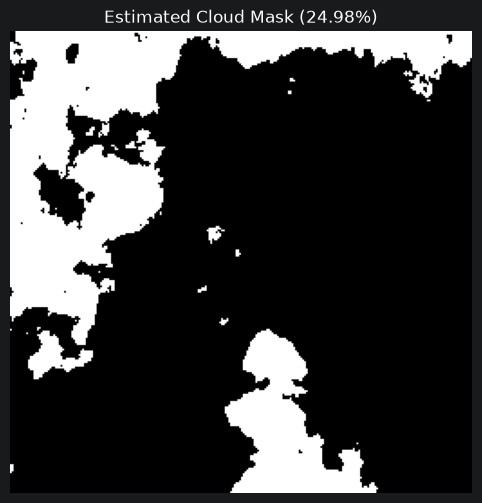

In [31]:
def detect_clouds(fcc):
    nir = fcc[:, :, 0].astype(np.float32)
    red = fcc[:, :, 1].astype(np.float32)
    green = fcc[:, :, 2].astype(np.float32)

    brightness = (nir + red + green) / 3.0

    max_band = np.maximum.reduce([nir, red, green])
    min_band = np.minimum.reduce([nir, red, green])

    whiteness = 1.0 - (max_band - min_band) / (max_band + 1e-6)

    nir_red_ratio = nir / (red + 1e-6)

    cloud_mask = (
        (brightness > np.percentile(brightness, 75)) &
        (whiteness > 0.85) &
        (nir_red_ratio < 1.5)
    )

    return cloud_mask


cloud_mask = detect_clouds(cloudy_fcc)

cloud_percentage = np.mean(cloud_mask) * 100

print("Estimated cloud percentage:", round(cloud_percentage, 2), "%")

plt.figure(figsize=(6, 6))
plt.imshow(cloud_mask, cmap="gray")
plt.title(f"Estimated Cloud Mask ({cloud_percentage:.2f}%)")
plt.axis("off")
plt.show()

In [33]:
L_MAX = {
    "B2": 52.0,
    "B3": 47.0,
    "B4": 31.5
}

def normalize_liss4(fcc):
    output = np.zeros_like(fcc, dtype=np.float32)

    output[:, :, 0] = (
        fcc[:, :, 0].astype(np.float32) / 1023.0
    ) * L_MAX["B4"]

    output[:, :, 1] = (
        fcc[:, :, 1].astype(np.float32) / 1023.0
    ) * L_MAX["B3"]

    output[:, :, 2] = (
        fcc[:, :, 2].astype(np.float32) / 1023.0
    ) * L_MAX["B2"]

    return output


cloudy_rad = normalize_liss4(cloudy_fcc)
clear_rad = normalize_liss4(clear_fcc)

for name, image in [("Cloudy", cloudy_rad), ("Non-cloudy", clear_rad)]:
    print(f"\n{name}")

    for channel, band in enumerate(["B4", "B3", "B2"]):
        values = image[:, :, channel]

        print(
            f"{band}: "
            f"min={values.min():.3f}, "
            f"max={values.max():.3f}, "
            f"mean={values.mean():.3f}"
        )


Cloudy
B4: min=8.437, max=16.628, mean=13.563
B3: min=9.005, max=24.212, mean=18.328
B2: min=11.284, max=26.432, mean=20.599

Non-cloudy
B4: min=1.755, max=8.191, mean=4.469
B3: min=1.930, max=5.238, mean=3.038
B2: min=3.202, max=5.337, mean=3.927


In [34]:
for name, image in [("Cloudy", cloudy_rad), ("Non-cloudy", clear_rad)]:
    print(f"\n{name}")

    brightness = np.mean(image, axis=2)

    print("Brightness:")
    print(
        "min =", brightness.min(),
        "max =", brightness.max(),
        "mean =", brightness.mean()
    )

    print("\nPercentiles:")
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(
            f"{p}%:",
            np.percentile(brightness, p)
        )


Cloudy
Brightness:
min = 10.219127 max = 22.249918 mean = 17.496616

Percentiles:
1%: 12.397696
5%: 13.929781
25%: 16.040201
50%: 17.661942
75%: 19.209719
95%: 20.440739
99%: 21.17562

Non-cloudy
Brightness:
min = 2.4183772 max = 5.3696647 mean = 3.811374

Percentiles:
1%: 3.2884245
5%: 3.454179
25%: 3.6446724
50%: 3.77289
75%: 3.9385796
95%: 4.31362
99%: 4.6332684


In [35]:
import os
from PIL import Image

generated = 0

with rasterio.open(cloudy_files["B2"]) as cb2, \
     rasterio.open(cloudy_files["B3"]) as cb3, \
     rasterio.open(cloudy_files["B4"]) as cb4, \
     rasterio.open(non_cloudy_files["B2"]) as nb2, \
     rasterio.open(non_cloudy_files["B3"]) as nb3, \
     rasterio.open(non_cloudy_files["B4"]) as nb4:

    for row in range(0, 16198 - PATCH_SIZE + 1, STRIDE):

        if generated >= MAX_PATCHES:
            break

        for col in range(0, 18153 - PATCH_SIZE + 1, STRIDE):

            if generated >= MAX_PATCHES:
                break

            cloudy_window = Window(
                193 + col,
                row,
                PATCH_SIZE,
                PATCH_SIZE
            )

            clear_window = Window(
                col,
                22 + row,
                PATCH_SIZE,
                PATCH_SIZE
            )

            cloudy_b2 = cb2.read(1, window=cloudy_window)
            cloudy_b3 = cb3.read(1, window=cloudy_window)
            cloudy_b4 = cb4.read(1, window=cloudy_window)

            clear_b2 = nb2.read(1, window=clear_window)
            clear_b3 = nb3.read(1, window=clear_window)
            clear_b4 = nb4.read(1, window=clear_window)

            cloudy_valid = np.mean(cloudy_b2 > 0)
            clear_valid = np.mean(clear_b2 > 0)

            if cloudy_valid < MIN_VALID or clear_valid < MIN_VALID:
                continue

            cloudy = np.stack(
                [cloudy_b4, cloudy_b3, cloudy_b2],
                axis=-1
            )

            clear = np.stack(
                [clear_b4, clear_b3, clear_b2],
                axis=-1
            )

            cloudy_uint8 = np.clip(
                cloudy.astype(np.float32) /
                np.array([1023, 1023, 1023]) * 255,
                0,
                255
            ).astype(np.uint8)

            clear_uint8 = np.clip(
                clear.astype(np.float32) /
                np.array([1023, 1023, 1023]) * 255,
                0,
                255
            ).astype(np.uint8)

            patch_name = f"{PAIR_NAME}_patch_{generated + 1:05d}.png"

            Image.fromarray(cloudy_uint8).save(
                os.path.join(CLOUDY_PATCH_DIR, patch_name)
            )

            Image.fromarray(clear_uint8).save(
                os.path.join(NON_CLOUDY_PATCH_DIR, patch_name)
            )

            generated += 1

print("Generated paired patches:", generated)

Generated paired patches: 50


Cloudy patches: 50
Non-cloudy patches: 50

First 5 cloudy files:
['gumla2_patch_00001.png', 'gumla2_patch_00002.png', 'gumla2_patch_00003.png', 'gumla2_patch_00004.png', 'gumla2_patch_00005.png']

First 5 non-cloudy files:
['gumla2_patch_00001.png', 'gumla2_patch_00002.png', 'gumla2_patch_00003.png', 'gumla2_patch_00004.png', 'gumla2_patch_00005.png']

Cloudy image shape: (256, 256, 3)
Non-cloudy image shape: (256, 256, 3)
Cloudy dtype: uint8
Non-cloudy dtype: uint8


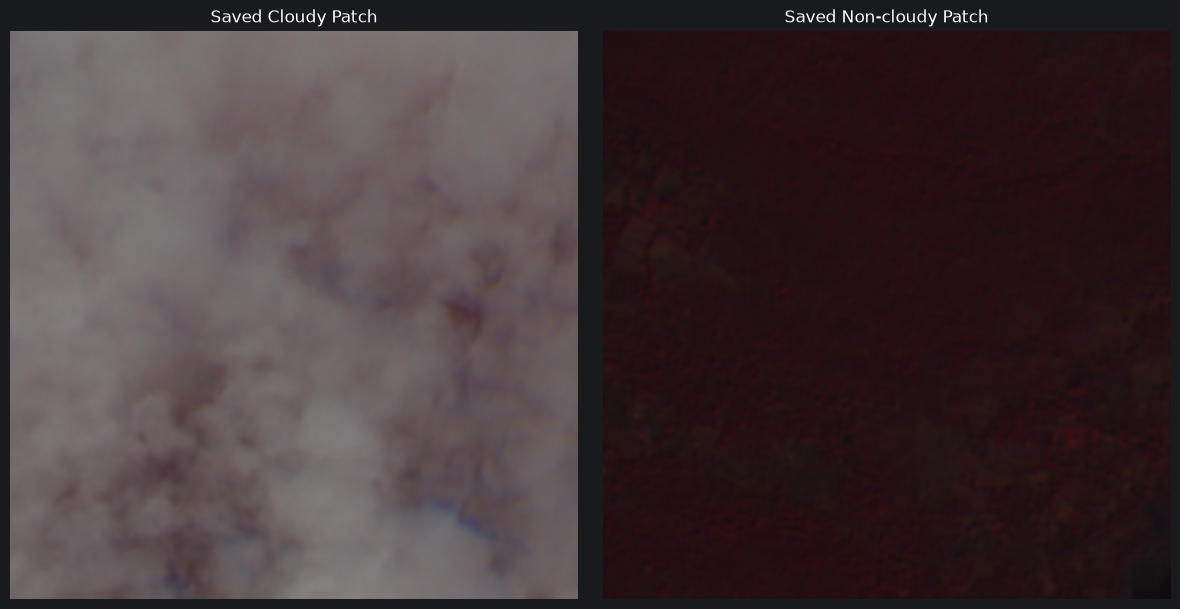

In [36]:
cloudy_names = sorted(os.listdir(CLOUDY_PATCH_DIR))
clear_names = sorted(os.listdir(NON_CLOUDY_PATCH_DIR))

print("Cloudy patches:", len(cloudy_names))
print("Non-cloudy patches:", len(clear_names))

print("\nFirst 5 cloudy files:")
print(cloudy_names[:5])

print("\nFirst 5 non-cloudy files:")
print(clear_names[:5])

sample_name = cloudy_names[0]

cloudy_path = os.path.join(CLOUDY_PATCH_DIR, sample_name)
clear_path = os.path.join(NON_CLOUDY_PATCH_DIR, sample_name)

cloudy_img = np.array(Image.open(cloudy_path))
clear_img = np.array(Image.open(clear_path))

print("\nCloudy image shape:", cloudy_img.shape)
print("Non-cloudy image shape:", clear_img.shape)
print("Cloudy dtype:", cloudy_img.dtype)
print("Non-cloudy dtype:", clear_img.dtype)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cloudy_img)
plt.title("Saved Cloudy Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clear_img)
plt.title("Saved Non-cloudy Patch")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
def cloud_fraction_simple(fcc):
    fcc = fcc.astype(np.float32)

    b4 = fcc[:, :, 0]
    b3 = fcc[:, :, 1]
    b2 = fcc[:, :, 2]

    brightness = (b4 + b3 + b2) / 3.0

    cloud_like = brightness > 550

    return np.mean(cloud_like)


fraction = cloud_fraction_simple(cloudy_fcc)

print("Cloud-like fraction:", fraction)
print("Cloud-like percentage:", fraction * 100)

Cloud-like fraction: 0.0
Cloud-like percentage: 0.0


Estimated cloud percentage: 0.0 %


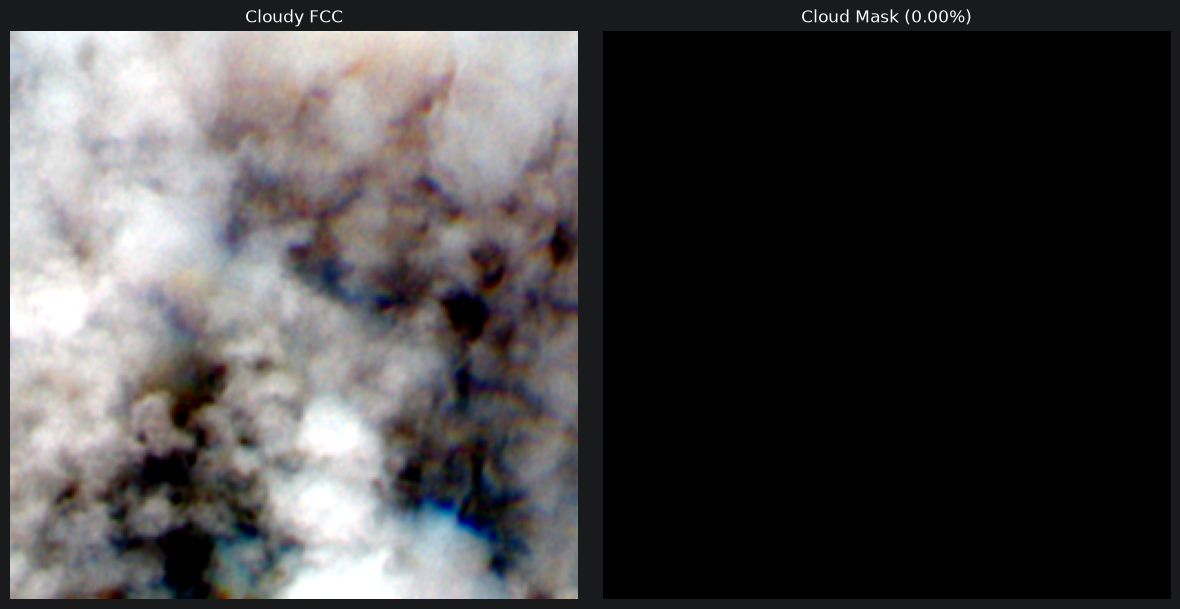

In [39]:
def cloud_mask_normalized(image):
    nir = image[:, :, 0]
    red = image[:, :, 1]
    green = image[:, :, 2]

    brightness = (nir + red + green) / 3.0

    max_band = np.maximum.reduce([nir, red, green])
    min_band = np.minimum.reduce([nir, red, green])

    whiteness = 1.0 - (
        (max_band - min_band) / (brightness + 1e-6)
    )

    mask = (
        (brightness > 17.0) &
        (whiteness > 0.80)
    )

    return mask


cloud_mask = cloud_mask_normalized(cloudy_rad)

cloud_percentage = np.mean(cloud_mask) * 100

print("Estimated cloud percentage:", round(cloud_percentage, 2), "%")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cloudy_display)
plt.title("Cloudy FCC")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cloud_mask, cmap="gray")
plt.title(f"Cloud Mask ({cloud_percentage:.2f}%)")
plt.axis("off")

plt.tight_layout()
plt.show()